# TP — Reconnaissance de chiffres manuscrits avec un CNN (Deep Learning)

**Objectif** : comprendre les étapes complètes d'un projet de Deep Learning avec un réseau de neurones convolutif (CNN), appliqué au problème classique de *Digit Recognition* sur le dataset **MNIST** (images de chiffres manuscrits 0 à 9).

**Plan du TP** (selon les consignes) :

1. **Création du modèle** : choix des couches (Conv2D, MaxPool, Dense), des fonctions d'activation (ReLU, Softmax) et de l'optimizer (Adam).
2. **Entraînement du modèle** : comprendre les notions de *batch* (lot) et *epoch* (époque).
3. **Courbes de perte (Loss)** : savoir analyser les courbes d'entraînement et de validation pour diagnostiquer (sur-)apprentissage.
4. **Test et métriques** : accuracy, matrice de confusion, précision, rappel, F1-score.
5. **Déploiement du modèle** : sauvegarde et rechargement — l'équivalent PyTorch du `joblib` de scikit-learn.
6. **Utilisation dans une application** : fichier `app_mnist.py` qui ouvre une interface graphique pour dessiner un chiffre et le faire prédire par le modèle déployé.

> Tous les blocs de code sont **largement commentés** : chaque étape est expliquée
> pour que vous puissiez refaire le TP par vous-même au lieu de simplement le recopier.

## Partie 1 — Import des librairies et détection du matériel (CPU / GPU)

Nous utilisons **PyTorch**, la bibliothèque de Deep Learning de Facebook/Meta.
PyTorch manipule des **tenseurs** (généralisation des matrices) et sait les
calculer sur le **GPU** pour accélérer l'entraînement.

In [1]:
# ================================================================
# PARTIE 1 — IMPORTS & MATÉRIEL DE CALCUL
# ================================================================

import os
import time

import torch                                   # bibliothèque de Deep Learning principale
import torch.nn as nn                          # nn : définit toutes les COUCHES (Conv2d, Linear...)
import torch.nn.functional as F                # F : fonctions d'activation (relu, softmax...)
import torch.optim as optim                    # optim : les OPTIMIZERS (SGD, Adam, RMSprop)
import torchvision                             # gestion des datasets d'images
from torchvision import datasets, transforms   # datasets: MNIST / transforms: prétraitement
from torch.utils.data import DataLoader        # découpe les données en lots (batch)

import numpy as np                             # calculs numériques
import matplotlib.pyplot as plt                # courbes et visualisations

from sklearn.metrics import (                  # métriques de classification
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# ----------------------------------------------------------------
# 1.1 Détection automatique du matériel de calcul (GPU si possible)
# ----------------------------------------------------------------
# Un entraînement de réseau de neurones demande des millions d'opérations :
# le GPU les exécute en parallèle (beaucoup plus rapide que le CPU).
print(f"Version PyTorch : {torch.__version__}  |  torchvision : {torchvision.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU détecté : {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Aucun GPU détecté : utilisation du CPU (plus lent sur de gros modèles).")

print(f"Appareil de calcul utilisé -> {device}")

Version PyTorch : 2.13.0+cu126  |  torchvision : 0.28.0+cu126
GPU détecté : NVIDIA GeForce GTX 1050 Ti
Appareil de calcul utilisé -> cuda


## Partie 2 — Le dataset MNIST et sa préparation

**MNIST** = 70 000 images de chiffres manuscrits **en niveaux de gris**, de taille **28 × 28 pixels** :

* 60 000 images d'**entraînement** ;
* 10 000 images de **test** ;
* chaque image porte une étiquette (*label*) de **0 à 9** (10 classes).

C'est le « Hello World » du Deep Learning : petit, mais avec tous les concepts importants.

2 étapes de préparation du dataset :

1. **Vision + normalisation** : les pixels sont des entiers 0-255. `ToTensor` les
   convertit en réels 0–1, puis `Normalize` les centre/réduit (moyenne 0, écart-type 1)
   pour que l'apprentissage soit plus rapide et plus stable.
2. **Découpage** : *train* (apprentissage) / *validation* (contrôle pendant
   l'entraînement) / *test* (évaluation finale, jamais vue pendant l'apprentissage).

In [2]:
# ----------------------------------------------------------------
# 2.1 Téléchargement et inspection des données brutes
# ----------------------------------------------------------------
# La 1re exécution télécharge le dataset dans le dossier './data'
# (puis il reste en cache local). On charge une version simple (ToTensor).
trainset_brut = datasets.MNIST(root="./data", train=True,  download=True, transform=transforms.ToTensor())
testset_brut  = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

print(f"Nb d'images d'entraînement : {len(trainset_brut)}")
print(f"Nb d'images de test        : {len(testset_brut)}")

# Forme d'une image : (canal, hauteur, largeur).
image, label = trainset_brut[0]
print(f"Forme d'une image            : {image.shape}")
print(f"Valeurs min/max des pixels   : {image.min():.2f} / {image.max():.2f}  (0 = noir, 1 = blanc)")
print(f"Étiquette (label)            : {label}")

Nb d'images d'entraînement : 60000
Nb d'images de test        : 10000
Forme d'une image            : torch.Size([1, 28, 28])
Valeurs min/max des pixels   : 0.00 / 1.00  (0 = noir, 1 = blanc)
Étiquette (label)            : 5


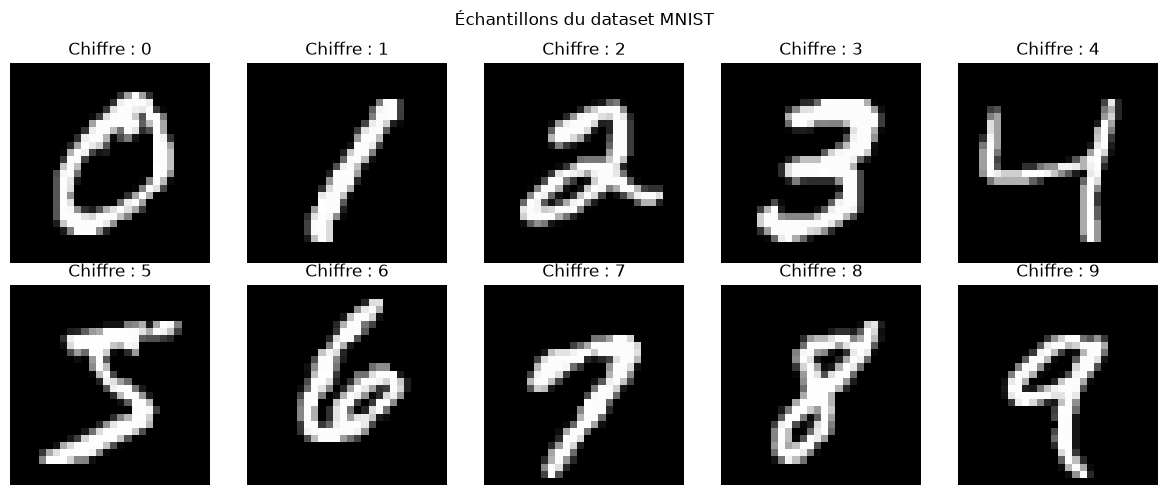

In [3]:
# ----------------------------------------------------------------
# 2.2 Visualisation : un exemple de chaque chiffre 0 à 9
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):                          # pour chaque chiffre 0..9
    idx = torch.nonzero(trainset_brut.targets == i)[0, 0].item()  # 1re image de ce chiffre
    img, lbl = trainset_brut[idx]
    axes[i].imshow(img.squeeze(), cmap="gray")   # squeeze(): (1,28,28) -> (28,28)
    axes[i].set_title(f"Chiffre : {lbl}")
    axes[i].axis("off")

plt.suptitle("Échantillons du dataset MNIST")
plt.tight_layout()
plt.show()

In [3]:
# ----------------------------------------------------------------
# 2.3 Chaîne de prétraitement (transforms.Compose)
# ----------------------------------------------------------------
# Compose applique une liste d'opérations dans l'ordre :
#   1. ToTensor() : image PIL -> tenseur PyTorch, pixels normalisés entre 0 et 1.
#   2. Normalize  : (pixel - moyenne) / écart-type  -> données centrées,
#      ce qui accélère la convergence et stabilise l'entraînement.
# Les valeurs (0.1307, 0.3081) sont la moyenne et l'écart-type réels de MNIST.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# On recharge les datasets AVEC cette chaîne de traitement.
trainset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
testset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

In [4]:
# ----------------------------------------------------------------
# 2.4 Séparation : entraînement / validation / test
# ----------------------------------------------------------------
# Les 60 000 images "train" sont reséparées en :
#   - 54 000 pour l'ENTRAÎNEMENT  (mise à jour des poids du réseau) ;
#   -  6 000 pour la VALIDATION   (contrôle à la fin de chaque époque,
#         indispensable pour détecter le sur-apprentissage).
# Le jeu de TEST (10 000) reste de côté : il ne sert JAMAIS pendant
# l'entraînement, uniquement à l'évaluation finale.
train_size, val_size = 54000, 6000
trainset, valset = torch.utils.data.random_split(
    trainset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)   # découpage reproductible
)

print(f"Entraînement : {len(trainset)} images")
print(f"Validation   : {len(valset)} images")
print(f"Test         : {len(testset)} images")

Entraînement : 54000 images
Validation   : 6000 images
Test         : 10000 images


In [5]:
# ----------------------------------------------------------------
# 2.5 Les DataLoader : distribuer les données par LOTS (batch)
# ----------------------------------------------------------------
# Un DataLoader découpe automatiquement le dataset en petits lots.
# Pourquoi des lots ?
#   * Impossible de tout charger en mémoire (54 000 images + gradients) ;
#   * mettre à jour les poids sur un petit lot à la fois est le principe
#     de la "descente de gradient stochastique" (SGD) : plus rapide et
#     plus robuste que sur tout le dataset.

#   batch_size : nb d'images traitées AVANT chaque mise à jour des poids.
#   shuffle    : mélange aléatoire à chaque époque (évite que le réseau
#                apprenne l'ordre des données).
BATCH_SIZE = 64

train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(valset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Lots par époque (train) : {len(train_loader)}  ->  {len(train_loader) * BATCH_SIZE} images")
print(f"Lots de validation      : {len(val_loader)}")
print(f"Lots de test            : {len(test_loader)}")

Lots par époque (train) : 844  ->  54016 images
Lots de validation      : 94
Lots de test            : 157


## Partie 3 — Création du modèle CNN (couches et fonctions d'activation)

Un **CNN (Convolutional Neural Network)** est un réseau conçu pour les images.
Il se compose de **deux grandes parties** :

### A) Partie convolutionnelle = extraction des caractéristiques
| Couche | Rôle |
|---|---|
| `nn.Conv2d` | Un **filtre** (petite fenêtre 3×3) balaie l'image pour détecter des motifs locaux : bords, courbes, formes. Plusieurs filtres = plusieurs « cartes ». |
| `ReLU` | *max(0, x)* : introduit la **non-linéarité** (sans elle, empiler les couches = une seule transformation linéaire). Évite le *vanishing gradient*. |
| `nn.MaxPool2d` | Réduit la taille (28×28 → 14×14) en gardant les maxima locaux : robustesse aux décalages + moins de calcul. |

### B) Partie de classification = prise de décision
| Couche | Rôle |
|---|---|
| `nn.Flatten` | « Aplatit » les cartes 2D (64×7×7) en un vecteur 1D (3136 valeurs). |
| `nn.Linear` (Dense) | Couche entièrement connectée qui combine les caractéristiques pour décider. |
| `nn.Dropout` | Désactive aléatoirement un % de neurones pendant l'entraînement → **régularisation** (anti sur-apprentissage). |
| `Softmax` | Convertit les 10 valeurs de sortie en **probabilités** (somme = 1). |

> Cette architecture est un « mini-VGG » : des blocs `[Conv → Conv → Pool]` suivis
> de couches denses. Simple, efficace, et parfaite pour MNIST.

In [7]:
# ----------------------------------------------------------------
# 3.1 Définition de l'architecture du réseau
# ----------------------------------------------------------------
class CNN(nn.Module):
    """Réseau de neurones convolutif : classe les images 28x28 en 10 chiffres.

    Toute architecture s'écrit en 2 méthodes (obligatoires car héritées de nn.Module) :
      - __init__() : déclaration des couches ;
      - forward()  : le chemin que suivent les données (du tenseur d'entrée
                     au tenseur de sortie).
    """

    def __init__(self):
        super().__init__()

        # ---- Bloc convolutionnel 1 : motifs simples ----
        # Conv2d(in_channels, out_channels, kernel_size, padding)
        #   in_channels = 1   : image en niveaux de gris (1 seul canal)
        #   out_channels = 32 : on apprend 32 filtres différents
        #   kernel_size = 3   : fenêtre d'analyse 3x3 pixels
        #   padding = 1       : bordure de zéros -> sortie de même taille 28x28
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        # Pooling : divise la taille par 2 -> 28x28 devient 14x14
        self.pool1 = nn.MaxPool2d(2)

        # ---- Bloc convolutionnel 2 : motifs plus complexes ----
        # On passe de 32 à 64 filtres : le réseau apprend des motifs de plus
        # en plus abstraits (combinaisons des motifs du 1er bloc).
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        # Pooling : 14x14 -> 7x7
        self.pool2 = nn.MaxPool2d(2)

        # ---- Partie classification ----
        # Après les 2 blocs : 64 cartes de 7x7 = 64*7*7 = 3136 valeurs.
        self.flatten = nn.Flatten()                 # vecteur 1D
        self.fc1 = nn.Linear(64 * 7 * 7, 128)       # couche dense 3136 -> 128
        self.fc2 = nn.Linear(128, 10)               # 128 -> 10 (un score par chiffre)
        self.dropout = nn.Dropout(0.25)             # 25 % de neurones coupés au hasard

    def forward(self, x):
        """Chemin des données : x a la forme (batch, 1, 28, 28)."""
        # Bloc 1 : conv -> activation -> conv -> activation -> pooling
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool1(x)

        # Bloc 2 : idem
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = self.pool2(x)

        # Classification
        x = self.flatten(x)          # (batch, 3136)
        x = torch.relu(self.fc1(x))  # activation après la couche dense
        x = self.dropout(x)          # régularisation (active seulement en entraînement)
        x = self.fc2(x)              # "logits" : valeurs brutes, PAS encore de probabilités
        return x


# Instanciation du modèle, puis envoi sur GPU/CPU.
# Pourquoi .to(device) ? Les poids et les données doivent être au même endroit.
model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


In [8]:
# ----------------------------------------------------------------
# 3.2 Vérification de la forme des sorties et du nombre de paramètres
# ----------------------------------------------------------------
# On fait passer un faux lot de 16 images aléatoires pour vérifier les dimensions.
x_fake = torch.randn(16, 1, 28, 28).to(device)   # (nb_images, canal, H, W)
y_fake = model(x_fake)
print(f"Entrée : {x_fake.shape} -> Sortie : {y_fake.shape}")
print("-> 16 images, 10 scores chacune (un score par chiffre 0..9)")

# Nombre total de paramètres (poids) à apprendre :
n_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres apprenables : {n_params:,}")

# Logits de la 1re image (valeurs brutes) :
logits_ex = y_fake[0].detach().cpu().numpy()
print(f"Exemple de logits : {logits_ex.round(2)}")

# Après softmax, ces scores deviennent des probabilités dont la somme vaut 1.
proba_ex = torch.softmax(y_fake[0], dim=0).detach().cpu().numpy()
print(f"Après softmax (somme = {proba_ex.sum():.3f}) : {proba_ex.round(3)}")

Entrée : torch.Size([16, 1, 28, 28]) -> Sortie : torch.Size([16, 10])
-> 16 images, 10 scores chacune (un score par chiffre 0..9)
Nombre de paramètres apprenables : 467,818
Exemple de logits : [-0.08  0.06 -0.07 -0.05  0.07 -0.01  0.06  0.06  0.01  0.09]
Après softmax (somme = 1.000) : [0.091 0.104 0.092 0.094 0.105 0.097 0.105 0.105 0.1   0.108]


## Partie 4 — Fonction de perte (Loss) et Optimizer

* **Fonction de perte — `CrossEntropyLoss`** : mesure l'écart entre la prédiction
  du réseau et la vraie réponse. Pour de la classification, on compare la
  distribution de probabilités prédite à la classe réelle via une **entropie
  croisée**. Plus la perte est **faible**, mieux le modèle prédit. C'est cette
  valeur que l'on cherche à **minimiser**.

  > Astuce PyTorch : `CrossEntropyLoss` combine déjà le Softmax + la perte.
  > C'est pourquoi `fc2` renvoie des logits bruts (pas de Softmax dans forward).

* **Optimizer — `Adam`** : l'algorithme qui **met à jour les poids** pour réduire
  la perte. Il suit la direction du **gradient** (descente de gradient) calculé
  par *rétropropagation*. Adam = pas d'apprentissage adaptatif + inertie
  (momentum) : le choix par défaut en pratique.

* **Learning rate (`lr`)** : taille des pas vers le minimum. Trop grand → la perte
  diverge ; trop petit → l'apprentissage est très lent. `0.001` est un bon départ.

In [9]:
# ----------------------------------------------------------------
# 4.1 Définition de la perte et de l'optimizer
# ----------------------------------------------------------------
# CrossEntropyLoss attend : les logits (sortie du modèle) + les labels (entiers 0-9).
criterion = nn.CrossEntropyLoss()

# Adam(parameters, lr) : on lui donne TOUS les poids du modèle et le taux
# d'apprentissage. Le gradient est calculé pour chaque paramètre.
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Fonction de perte : CrossEntropyLoss")
print("Optimizer         : Adam  (learning rate = 0.001)")

Fonction de perte : CrossEntropyLoss
Optimizer         : Adam  (learning rate = 0.001)


## Partie 5 — Entraînement du modèle (batch & epoch)

### Vocabulaire à maîtriser (questions classiques de TP/exam)
* **Époque (epoch)** : un passage **complet** du réseau sur toutes les images
  d'entraînement (ici les 54 000). Plus il y a d'époques, plus le modèle « voit »
  les données (autant de fois).
* **Lot (batch)** : un sous-ensemble d'images (ici 64). Les poids ne sont mis à
  jour qu'à la **fin de chaque lot**.
  * 1 époque = 54000 / 64 ≈ **844 lots** = 844 mises à jour de poids.
* **Itération** : traitement d'un seul lot.

### Le cycle d'entraînement par lot (à connaître par cœur) :
1. **Forward** : prédiction du réseau sur le lot.
2. **Perte** : calcul de l'erreur (criterion) entre prédiction et vérité.
3. **Backward** : `loss.backward()` calcule le gradient (dérivée) de la perte
   par rapport à chaque poids.
4. **Update** : `optimizer.step()` déplace chaque poids dans le sens qui
   **réduit** la perte.
5. **Reset** : `optimizer.zero_grad()` remet les gradients à zéro (sans quoi ils
   s'accumuleraient de lot en lot).

### L'évaluation de validation à chaque époque :
`model.eval()` + `torch.no_grad()` : sans dropout et sans calcul de gradient.
Le réseau prédit sur la validation pour **surveiller** l'apparition d'un
sur-apprentissage.

In [10]:
# ----------------------------------------------------------------
# 5.1 Fonction d'entraînement d'UNE époque
# ----------------------------------------------------------------
def entrainer_une_epoch(model, loader, criterion, optimizer, device):
    """Parcourt tous les lots d'UN loader et met à jour les poids.

    Retourne (perte_moyenne, accuracy) sur l'ensemble des images de l'époque.
    """
    model.train()        # mode ENTRAÎNEMENT : dropout actif, gradients activés
    perte_totale = 0.0   # accumulateur des pertes (pondérées par la taille du lot)
    corrects = 0         # compteur de bonnes prédictions
    total = 0            # nombre total d'images vues

    for images, labels in loader:              # pour chaque lot
        images, labels = images.to(device), labels.to(device)   # sur GPU/CPU

        # --- 1) PRÉDICTION (forward) ---
        predictions = model(images)

        # --- 2) CALCUL DE LA PERTE ---
        perte = criterion(predictions, labels)

        # --- 3) RÉINITIALISATION + CALCUL DES GRADIENTS (backward) ---
        optimizer.zero_grad()   # gradients a zero (sinon accumulation)
        perte.backward()        # propage l'erreur -> calcule les derivees

        # --- 4) MISE À JOUR DES POIDS ---
        optimizer.step()

        # --- statistiques ---
        perte_totale += perte.item() * images.size(0)   # perte moyenne pondérée
        _, predits = torch.max(predictions, 1)          # classe la plus probable
        corrects  += (predits == labels).sum().item()   # nb de bonnes réponses
        total     += labels.size(0)

    return perte_totale / total, corrects / total

In [11]:
# ----------------------------------------------------------------
# 5.2 Fonction d'évaluation (validation ou test) SANS modifier les poids
# ----------------------------------------------------------------
def evaluer(model, loader, criterion, device):
    """Mesure la perte et l'accuracy sans entraîner le modèle."""
    model.eval()         # mode ÉVALUATION : dropout désactivé (déterministe)
    perte_totale = 0.0
    corrects = 0
    total = 0

    with torch.no_grad():            # on COUPE le calcul de gradient : plus rapide
        for images, labels in loader:#  et moins de mémoire (inutile ici)
            images, labels = images.to(device), labels.to(device)
            predictions = model(images)
            perte = criterion(predictions, labels)

            perte_totale += perte.item() * images.size(0)
            _, predits = torch.max(predictions, 1)
            corrects += (predits == labels).sum().item()
            total    += labels.size(0)

    return perte_totale / total, corrects / total

In [12]:
# ----------------------------------------------------------------
# 5.3 Lancement de l'entraînement sur plusieurs époques
# ----------------------------------------------------------------
NB_EPOCHS = 8        # nb de passages complets sur les données d'entraînement

# On mémorise pertes et accuracies de chaque époque pour la Partie 6.
historique = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

t0 = time.time()
for epoch in range(1, NB_EPOCHS + 1):
    tr_loss, tr_acc = entrainer_une_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc = evaluer(model, val_loader, criterion, device)

    historique["train_loss"].append(tr_loss)
    historique["val_loss"].append(va_loss)
    historique["train_acc"].append(tr_acc)
    historique["val_acc"].append(va_acc)

    print(f"Époque {epoch:2d}/{NB_EPOCHS} | "
          f"Train -> perte {tr_loss:.4f}, acc {tr_acc:.4f} | "
          f"Val   -> perte {va_loss:.4f}, acc {va_acc:.4f}")

print(f"\nEntraînement terminé en {time.time() - t0:.1f} s.")
print(f"Meilleure accuracy de validation : {max(historique['val_acc']):.4f}")

Époque  1/8 | Train -> perte 0.1651, acc 0.9489 | Val   -> perte 0.0623, acc 0.9820


Époque  2/8 | Train -> perte 0.0529, acc 0.9840 | Val   -> perte 0.0411, acc 0.9883


Époque  3/8 | Train -> perte 0.0368, acc 0.9887 | Val   -> perte 0.0440, acc 0.9878


Époque  4/8 | Train -> perte 0.0297, acc 0.9906 | Val   -> perte 0.0327, acc 0.9908


Époque  5/8 | Train -> perte 0.0239, acc 0.9927 | Val   -> perte 0.0337, acc 0.9915


Époque  6/8 | Train -> perte 0.0215, acc 0.9934 | Val   -> perte 0.0371, acc 0.9912


Époque  7/8 | Train -> perte 0.0171, acc 0.9946 | Val   -> perte 0.0330, acc 0.9903


Époque  8/8 | Train -> perte 0.0152, acc 0.9953 | Val   -> perte 0.0355, acc 0.9917

Entraînement terminé en 196.5 s.
Meilleure accuracy de validation : 0.9917


## Partie 6 — Analyse des courbes de perte (Loss)

Les courbes sont **l'outil de diagnostic n°1** d'un apprentissage.
On compare d'époque en époque deux courbes :

* **Perte d'entraînement (train)** : ce que voit le modèle sur les données qu'il apprend.
* **Perte de validation (val)** : ce que fait le modèle sur des données **jamais vues**
  pendant l'entraînement. C'est la courbe qui compte vraiment !

### Interprétation (à connaître) :
| Situation | Symptôme | Remède possible |
|---|---|---|
| **Sous-apprentissage** | pertes train ET val élevées, courbes à plat | + d'époques, modèle plus grand, lr plus grand |
| **Bon apprentissage** | train ↓ et val ↓ puis plateau, proches l'une de l'autre | c'est le cas idéal |
| **Sur-apprentissage (overfitting)** | train ↓ mais val stagne ou REMONTE (ou écart qui grandit) | + dropout, + données, *early stopping* |

> Notre modèle étant petit pour MNIST, on aura éventuellement un **léger
> sur-apprentissage** : parfait pour l'illustrer concrètement !

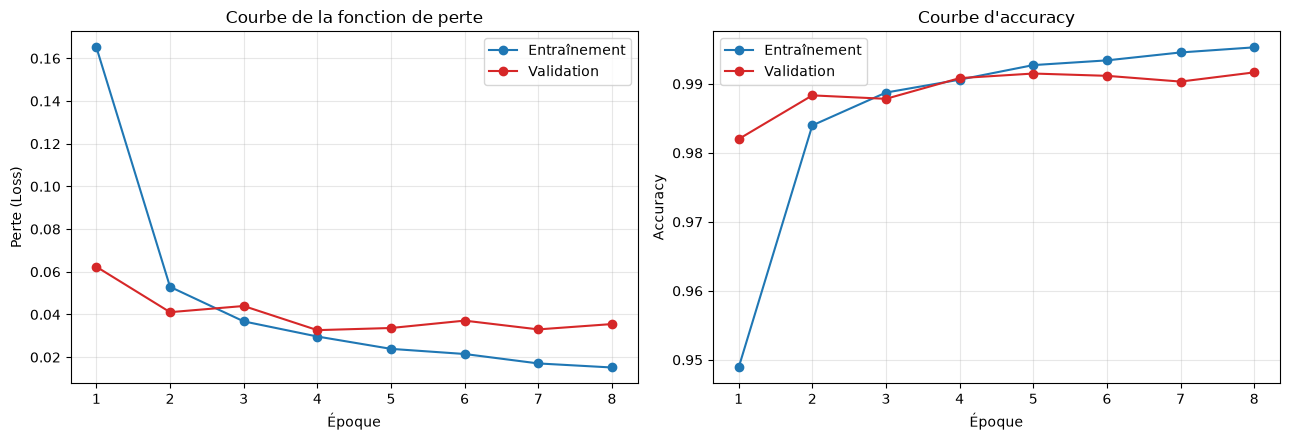

In [13]:
# ----------------------------------------------------------------
# 6.1 Affichage des courbes de perte et d'accuracy
# ----------------------------------------------------------------
epoques = range(1, NB_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Courbe de la fonction de perte (LOSS) ---
ax1.plot(epoques, historique["train_loss"], "o-", label="Entraînement", color="tab:blue")
ax1.plot(epoques, historique["val_loss"],   "o-", label="Validation",   color="tab:red")
ax1.set_xlabel("Époque")
ax1.set_ylabel("Perte (Loss)")
ax1.set_title("Courbe de la fonction de perte")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Courbe d'accuracy (exactitude) ---
ax2.plot(epoques, historique["train_acc"], "o-", label="Entraînement", color="tab:blue")
ax2.plot(epoques, historique["val_acc"],   "o-", label="Validation",   color="tab:red")
ax2.set_xlabel("Époque")
ax2.set_ylabel("Accuracy")
ax2.set_title("Courbe d'accuracy")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Analyse demandée (à rédiger dans votre compte-rendu, exemples de réponses)

* La perte (train comme val) **diminue** fortement puis **stagne** : le modèle apprend vite puis se stabilise.
* Les deux courbes restent **proches** (gap faible) → peu ou pas de sur-apprentissage.
  Si l'écart train/val s'élargissait, ce serait le signe d'un overfitting (le
  réseau « apprend par cœur », mais ne généralise pas).
* L'accuracy de validation dépasse **~98 %** dès la 2ᵉ-3ᵉ époque : MNIST est un
  dataset « facile » et l'architecture est adaptée.
* Si vous vouliez améliorer encore : augmenter légèrement les époques + `Dropout`,
  ou faire un *learning rate scheduler* (diminuer le lr en cours d'entraînement).

## Partie 7 — Test et métriques d'évaluation

L'**accuracy** seule peut cacher de grosses erreurs (ex. un modèle qui ne prédit
jamais le chiffre « 8 » mais qui est bon partout ailleurs). On complète donc par :

* **Matrice de confusion** : lignes = vraie classe, colonnes = classe prédite.
  Toutes les valeurs hors diagonale = erreurs (faciles à repérer).
* **Précision** = VP / (VP + FP) : « quand je prédits *X*, ai-je souvent raison ? »
* **Rappel (recall)** = VP / (VP + FN) : « ai-je bien retrouvé tous les vrais *X* ? »
* **F1-score** = moyenne harmonique de précision et rappel (un seul chiffre qui résume).

*VP = vrais positifs, FP = faux positifs, FN = faux négatifs.*

In [14]:
# ----------------------------------------------------------------
# 7.1 Évaluation finale sur le jeu de TEST (jamais vu à l'entraînement)
# ----------------------------------------------------------------
test_loss, test_acc = evaluer(model, test_loader, criterion, device)
print(f"PERFORMANCE SUR LE TEST : perte = {test_loss:.4f} | accuracy = {test_acc:.4f}")
print(f"                        soit environ {test_acc * 100:.2f} % de bonnes réponses")

PERFORMANCE SUR LE TEST : perte = 0.0301 | accuracy = 0.9918
                        soit environ 99.18 % de bonnes réponses


              precision    recall  f1-score   support

           0      0.986     0.999     0.992       980
           1      0.996     0.995     0.996      1135
           2      0.993     0.995     0.994      1032
           3      0.988     0.998     0.993      1010
           4      0.997     0.984     0.990       982
           5      0.998     0.988     0.993       892
           6      0.997     0.987     0.992       958
           7      0.993     0.986     0.990      1028
           8      0.987     0.995     0.991       974
           9      0.983     0.990     0.987      1009

    accuracy                          0.992     10000
   macro avg      0.992     0.992     0.992     10000
weighted avg      0.992     0.992     0.992     10000



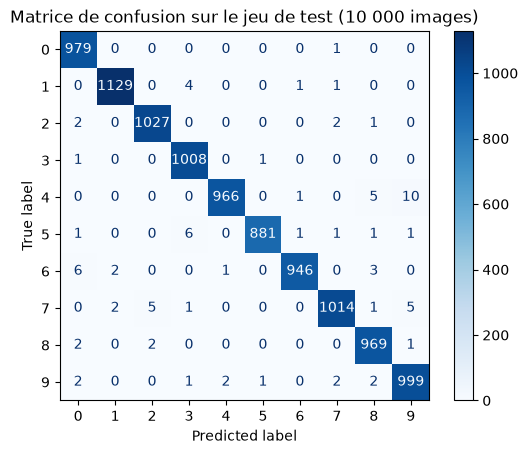

In [15]:
# ----------------------------------------------------------------
# 7.2 Matrice de confusion + rapport de classification (par classe)
# ----------------------------------------------------------------
def predire_tout(model, loader, device):
    """Renvoie (étiquettes vraies, étiquettes prédites) pour tout un loader."""
    y_vrai, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            _, predits = torch.max(logits, 1)
            y_vrai.extend(labels.tolist())
            y_pred.extend(predits.cpu().tolist())
    return y_vrai, y_pred

y_vrai, y_pred = predire_tout(model, test_loader, device)

# --- Rapport : précision, rappel, F1 pour chaque chiffre ---
print(classification_report(y_vrai, y_pred, digits=3))

# --- Matrice de confusion ---
cm = confusion_matrix(y_vrai, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[str(i) for i in range(10)])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion sur le jeu de test (10 000 images)") 
plt.show()

Nombre d'erreurs sur 10 000 images : 82


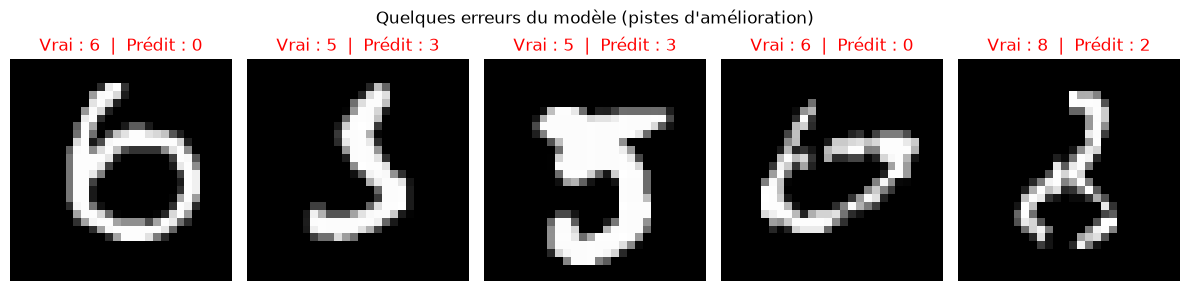

In [16]:
# ----------------------------------------------------------------
# 7.3 Analyse des erreurs : regarder ce que le modèle rate
# ----------------------------------------------------------------
erreurs = [i for i, (v, p) in enumerate(zip(y_vrai, y_pred)) if v != p]
print(f"Nombre d'erreurs sur 10 000 images : {len(erreurs)}")

fig, axes = plt.subplots(1, min(5, len(erreurs)), figsize=(12, 3))
if len(erreurs):
    for ax, i in zip(axes, erreurs[:5]):
        img = testset[i][0].squeeze()
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Vrai : {y_vrai[i]}  |  Prédit : {y_pred[i]}", color="red")
        ax.axis("off")
plt.suptitle("Quelques erreurs du modèle (pistes d'amélioration)")
plt.tight_layout()
plt.show()

# Les chiffres ambigus (tracés maladroits) expliquent la plupart des erreurs.
# On pourrait améliorer avec : augmentation de données, plus de couches, etc.

## Partie 8 — Déploiement du modèle (sauvegarde / rechargement)

Avec scikit-learn on sauvegarde un modèle avec `joblib.dump(model, "fichier")`.
Avec PyTorch, la convention est **différente** :

* On sauvegarde les **poids** du réseau (le `state_dict`) — et non l'objet entier.
  Les poids = la connaissance apprise pendant l'entraînement.
* L'**architecture** (les couches) reste définie dans le code de la classe `CNN` :
  pour charger le modèle, il faut redéfinir la même architecture, puis injecter
  les poids.
* Les fichiers `.pth` sont l'équivalent PyTorch des fichiers `.joblib` de scikit-learn.

**Pourquoi pas `torch.save(model, ...)` (objet entier) ?**
  Simplicité au premier abord, mais fragile et risqué : le fichier dépend de la
  version de PyTorch, et charger un fichier non fiable peut exécuter du code
  malveillant. La méthode `state_dict` est le **standard**.*

In [17]:
# ----------------------------------------------------------------
# 8.1 Sauvegarde du modèle entraîné (+ métadonnées)
# ----------------------------------------------------------------
dossier_modeles = "modele"
os.makedirs(dossier_modeles, exist_ok=True)
chemin_modele = os.path.join(dossier_modeles, "cnn_mnist.pth")

torch.save({
    "state_dict" : model.state_dict(),     # les poids du réseau (l'essentiel !)
    "accuracy"   : test_acc,               # performance de référence
    "epochs"     : NB_EPOCHS,
    "batch_size" : BATCH_SIZE,
    "optimizer"  : "Adam(lr=0.001)",
    "dataset"    : "MNIST",
}, chemin_modele)

print(f"Modèle sauvegardé dans : {chemin_modele}")
print(f"Taille du fichier      : {os.path.getsize(chemin_modele) / 1024:.1f} Ko")

Modèle sauvegardé dans : modele\cnn_mnist.pth
Taille du fichier      : 1832.3 Ko


In [18]:
# ----------------------------------------------------------------
# 8.2 Rechargement du modèle  (l'équivalent de joblib.load)
# ----------------------------------------------------------------
# ÉTAPE 1 : reconstruire la MÊME architecture (mêmes couches, mêmes tailles).
modele_charge = CNN().to(device)

# ÉTAPE 2 : charger le dictionnaire sauvegardé et injecter les poids.
sauvegarde = torch.load(chemin_modele, weights_only=True)
modele_charge.load_state_dict(sauvegarde["state_dict"])

# ÉTAPE 3 : mode inférence (dropout désactivé).
modele_charge.eval()

# VÉRIFICATION : le modèle rechargé doit retrouver exactement la même performance.
perte2, acc2 = evaluer(modele_charge, test_loader, criterion, device)
print(f"Modèle rechargé -> accuracy test = {acc2:.4f}  (avant sauvegarde : {test_acc:.4f})")

# Bonus : l'acc2 doit être (quasi) identique à test_acc. Si ce n'était pas le cas,
# l'architecture définie ne correspondrait pas à celle du fichier .pth !

Modèle rechargé -> accuracy test = 0.9918  (avant sauvegarde : 0.9918)


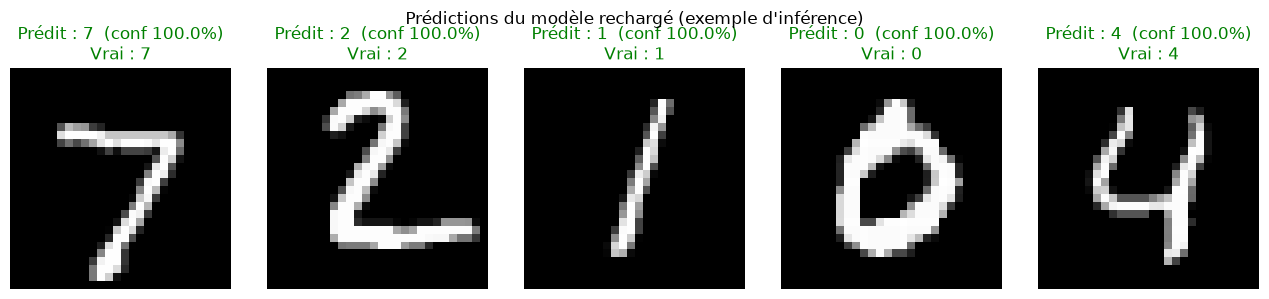

Probabilités de l'image n°0 : 0:0.0%, 1:0.0%, 2:0.0%, 3:0.0%, 4:100.0%, 5:0.0%, 6:0.0%, 7:0.0%, 8:0.0%, 9:0.0%


In [19]:
# ----------------------------------------------------------------
# 8.3 Démonstration : prédiction sur des images de test
#    (= ce que fera l'application dans la partie 9)
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for i, ax in enumerate(axes):
    img, vrai_label = testset[i]                          # image + label vrai
    logits = modele_charge(img.unsqueeze(0).to(device))   # unsqueeze(0): (1,1,28,28)
    proba  = torch.softmax(logits, dim=1).squeeze().cpu() # probabilités des 10 chiffres
    predit = int(proba.argmax())                          # chiffre le plus probable

    ax.imshow(testset_brut[i][0].squeeze(), cmap="gray")  # image brute 0-255
    ax.set_title(f"Prédit : {predit}  (conf {proba[predit]:.1%})\nVrai : {vrai_label}",
                 color="green" if predit == vrai_label else "red")
    ax.axis("off")

plt.suptitle("Prédictions du modèle rechargé (exemple d'inférence)")
plt.tight_layout()
plt.show()

# La distribution complète de probabilités de la 1re image :
print("Probabilités de l'image n°0 : " + ", ".join(
    f"{i}:{p:.1%}" for i, p in enumerate(proba)))

## Conclusion et prolongements

Vous avez réalisé le **cycle complet** d'un projet de Deep Learning :
données → prétraitement → architecture → entraînement → diagnostic (courbes) →
évaluation (métriques) → déploiement (sauvegarde/rechargement).

### Pistes pour aller plus loin
* **Jouer avec l'architecture** : 3e bloc de convolution, `kernel_size=5`,
  batch-normalisation (`nn.BatchNorm2d`).
* **Jouer avec l'optimizer** : `optim.SGD(momentum=0.9)` vs Adam, et un
  *learning rate scheduler* (`torch.optim.lr_scheduler`).
* **Lutter contre le sur-apprentissage** : réduire l'entraînement à 10 000 images,
  augmenter le dropout, ajouter de la *data augmentation* (`transforms.RandomRotation`).
* **Changer de dataset** : CIFAR-10 (images couleur 32×32, nettement plus dur).

### L'application finale (partie 9)
Le fichier **`app_mnist.py`**, fourni à côté de ce notebook, charge le modèle
`modele/cnn_mnist.pth` puis ouvre une **petite interface graphique** : vous
dessinez un chiffre à la souris sur un canevas 28×28 grossi 10 fois, et le réseau
prédit le chiffre en temps réel avec ses probabilités. C'est « l'utilisation dans
une application » demandée dans le TP.